# Diffusion Processes

A **diffusion process** is the general "bring your own model" random process. Every other process in Symbulate has a fixed shape and you pick some numbers. Here you describe the shape yourself, with two functions:

- **`drift(x, t)`** -- which way the path is pushed, and how hard. This is the predictable part.
- **`diffusion(x, t)`** -- how big the random shakes are.

Both can depend on where the path currently is (`x`) and on the time (`t`). That is what makes this general: a huge number of named models are just a choice of those two functions, and the table further down gives four of the standard ones.

One important difference from `BrownianMotion` and the other Gaussian processes: those are simulated **exactly**, while a general diffusion has no exact formula to sample from, so this one is an **approximation**. The `tol` parameter controls how good it is -- see the last section.

In [1]:
from symbulate import *

## Create a process and draw a path

The example below is *geometric Brownian motion*, the textbook stock price model. Both functions are proportional to `x`, so a price near 100 moves in bigger steps than a price near 1, and the path can never go negative. `x0` is where it starts.

Each draw is a function of continuous time, so evaluate it at any time `t >= 0`.

In [2]:
X = DiffusionProcess(
    drift=lambda x, t: 0.05 * x,
    diffusion=lambda x, t: 0.3 * x,
    x0=100,
)
path = X.draw()
[round(float(path(t)), 2) for t in [0, 1, 2, 5]]

[100.0, 135.99, 186.8, 228.94]

## Simulate and plot sample paths

It behaves like any other Symbulate random variable, so simulate and plot the paths the usual way.

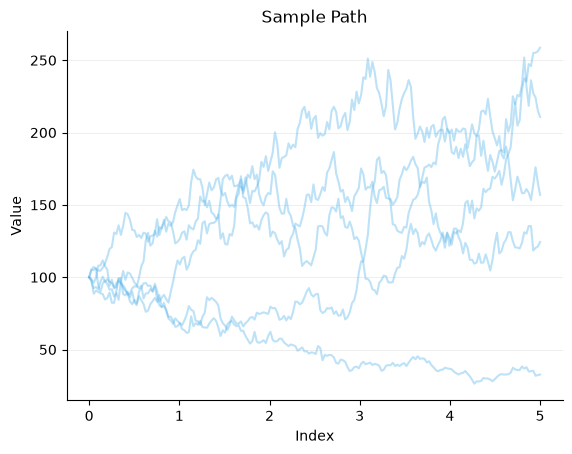

In [3]:
X.sim(5).plot(tmin=0, tmax=5)

## Four standard models

These are the recipes. Each one is the same `DiffusionProcess` call with different functions:

| Model | `drift(x, t)` | `diffusion(x, t)` |
|---|---|---|
| Brownian motion | `0` | `sigma` |
| Ornstein-Uhlenbeck (interest rate) | `rate * (mean - x)` | `sigma` |
| Geometric Brownian motion (stock price) | `mu * x` | `sigma * x` |
| Cox-Ingersoll-Ross (interest rate, stays positive) | `rate * (mean - x)` | `sigma * sqrt(x)` |

**Brownian motion** -- a flat drift of 0 and a constant shake size. No pull anywhere, so it wanders off.

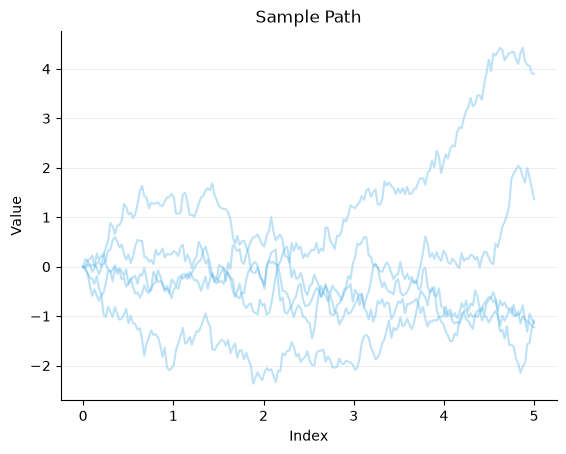

In [4]:
DiffusionProcess(
    drift=lambda x, t: 0,
    diffusion=lambda x, t: 1,
    x0=0,
).sim(5).plot(tmin=0, tmax=5)

**Ornstein-Uhlenbeck** -- the drift points back toward `mean`, and gets stronger the further away the path is. Started at 10 with a mean of 0, the paths get dragged down.

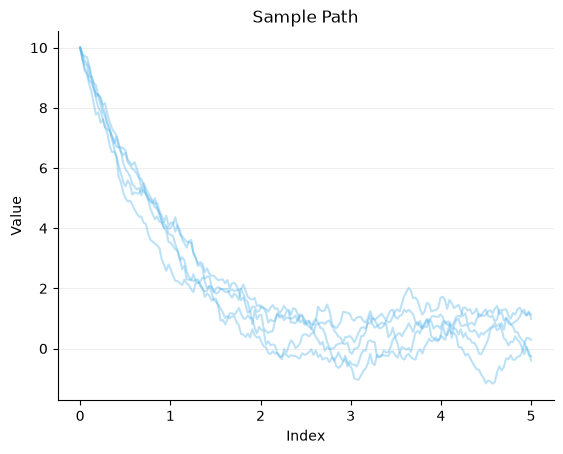

In [5]:
DiffusionProcess(
    drift=lambda x, t: 1.0 * (0 - x),
    diffusion=lambda x, t: 1,
    x0=10,
).sim(5).plot(tmin=0, tmax=5)

**Cox-Ingersoll-Ross** -- like Ornstein-Uhlenbeck, but the shake size shrinks as the path approaches 0, so it stays positive. That is why it is used for interest rates, which cannot sensibly go negative. Note the `max(x, 0)` inside the square root -- the next section explains why it is needed.

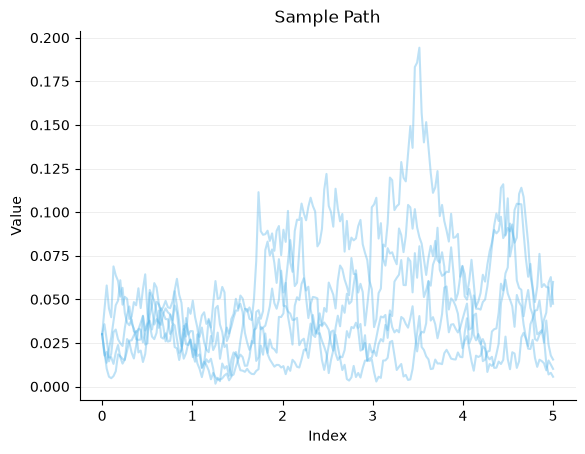

In [6]:
import numpy as np

DiffusionProcess(
    drift=lambda x, t: 2.0 * (0.05 - x),
    diffusion=lambda x, t: 0.3 * np.sqrt(max(x, 0)),
    x0=0.03,
).sim(5).plot(tmin=0, tmax=5)

## It agrees with the exact process

Symbulate has an exact `OrnsteinUhlenbeck` class, built as a Gaussian process. Writing the same model as a `DiffusionProcess` gives the approximate version. Comparing the two is a good way to see that the approximation is doing its job -- the long-run variance should be `scale**2 / (2 * rate)`, which here is `4 / 3` = 1.333.

In [7]:
rate, scale = 1.5, 2.0

approximate = DiffusionProcess(
    drift=lambda x, t: -rate * x,
    diffusion=lambda x, t: scale,
    x0=0,
)
exact = OrnsteinUhlenbeck(reversion_rate=rate, mean=0, scale=scale)

approximate[8.0].sim(2000).var(), exact[8.0].sim(2000).var()

(1.4096370089604355, 1.35884113737507)

## Watch out: square roots need a floor

The simulation moves forward in small steps, and a step can overshoot slightly past 0 even in a model that should never go negative. `np.sqrt` of a negative number is `nan`, and once one value is `nan` the rest of the path is too.

The fix is `max(x, 0)` inside the square root. Below is the same CIR model with a large `sigma`, which makes the problem easy to trigger -- without the floor almost every path is ruined.

In [8]:
import warnings


def count_ruined(diffusion_func):
    """How many of 20 paths come out as nan."""
    Y = DiffusionProcess(
        drift=lambda x, t: 1.0 * (0.05 - x),
        diffusion=diffusion_func,
        x0=0.05,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        values = [float(Y.draw()(3.0)) for _ in range(20)]
    return sum(np.isnan(v) for v in values)


print("without max(x, 0):", count_ruined(lambda x, t: 0.9 * np.sqrt(x)), "of 20 ruined")
print("with    max(x, 0):", count_ruined(lambda x, t: 0.9 * np.sqrt(max(x, 0))), "of 20 ruined")

without max(x, 0): 19 of 20 ruined
with    max(x, 0): 0 of 20 ruined


## The value at a fixed time

The value at a particular time is a random variable, so index the process with `X[t]` and treat it like any other. For the stock price model, the average after 2 years should be about `100 * exp(0.05 * 2)` = 110.5.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


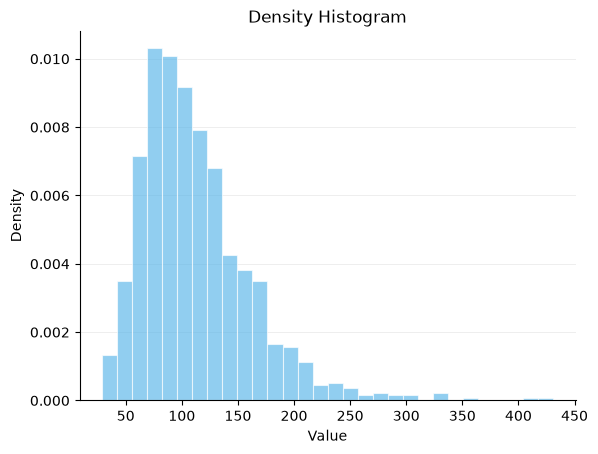

In [9]:
X[2.0].sim(1000).plot()

In [10]:
values = X[2.0].sim(1000)
values.mean(), values.var()

(111.7003835601083, 2470.895472548658)

## Zooming in refines the same path

This is the feature that makes a path more than just a list of numbers. Ask a path about a time in between two times it already knows, and it fills in the gap in a way that agrees with both neighbours -- it does **not** start a new random path. So the values you already saw never change.

In [11]:
path = X.draw()
before = path(1.0), path(2.0)

# Ask about lots of times in between
for t in [1.1, 1.25, 1.5, 1.75, 1.9]:
    path(t)

after = path(1.0), path(2.0)
before == after

True

## `tol`: accuracy against speed

`tol` is the finest time step the simulation will use. A smaller `tol` is closer to the true process but slower, because the path is built from more steps. The default is `1e-3`, which is fine for plotting.

For the constant-coefficient case (plain Brownian motion) the scheme is exact whatever `tol` you pick. It is only the state-dependent models -- geometric Brownian motion, CIR -- where `tol` affects accuracy.

See `diffusion_process_demo.py` in this folder for a side-by-side picture of one path viewed at two zoom levels.

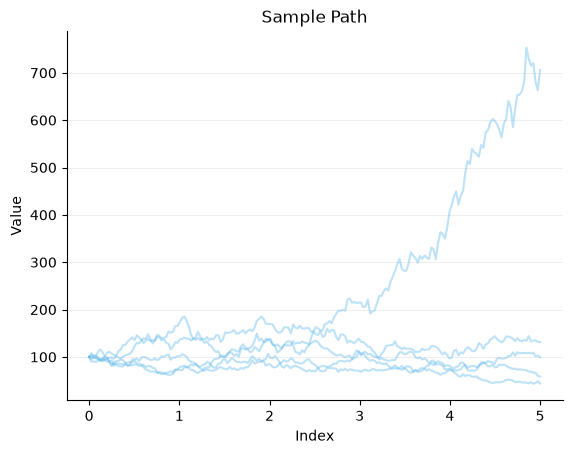

In [12]:
DiffusionProcess(
    drift=lambda x, t: 0.05 * x,
    diffusion=lambda x, t: 0.3 * x,
    x0=100,
    tol=1e-2,
).sim(5).plot(tmin=0, tmax=5)